# Chapter 39 — Layers and Multilayer Networks

## Learning goals

Chapter 38 introduced one neuron as a small function with weights, a bias, and an optional activation.

This chapter groups neurons into layers and connects layers into a small network.

By the end of this chapter, you should be able to:

1. Explain a layer as a group of neurons receiving the same inputs.
2. Explain a network as layers connected in sequence.
3. Build `SingleNeuron`, `Layer`, and `SmallNeuralNetwork` classes.
4. Run a forward pass through a multilayer network.
5. Count parameters in neurons, layers, and networks.
6. Train a small network with homemade scalar autograd.
7. Plot its training loss and compare predictions before and after training.
8. Explain why parameter counts grow quickly.

## From one neuron to a network

A single neuron maps several input numbers to one output number.

A layer contains several neurons, and every neuron in that layer receives the same input values.

If a layer contains three neurons, it returns three output values.

Those outputs can become the inputs to another layer:

```text
input values → hidden layer → output layer → prediction
```

This chapter builds the architecture `2 → 3 → 1`: two input values, three hidden units, and one output unit.

## Terms used in this chapter

- A **neuron** is a parameterized function that returns one number.
- A **layer** is a group of neurons receiving the same inputs.
- A **hidden layer** lies between the original inputs and final outputs.
- An **output layer** is the final layer in a network.
- A **network** connects layers in sequence.
- A **parameter** is a learnable weight or bias.
- A **forward pass** computes outputs from inputs.
- A **backward pass** computes gradients of a final value with respect to earlier values.
- A **parameter count** is the number of learnable scalar values in a model.

The weighted sum `w · x + b` is affine rather than strictly linear when the bias is nonzero.

## Rebuild homemade scalar autograd

`TrackedNumber` records scalar operations and applies their local backward rules in reverse topological order.

Parents are stored in tuples so graph traversal is deterministic.

Backward closures capture forward-time values so later parameter updates cannot change an old graph's derivatives.

In [1]:
from collections.abc import Callable, Sequence


class TrackedNumber:
    def __init__(
        self,
        data: float,
        previous_values: tuple["TrackedNumber", ...] = (),
        operation: str = "",
        label: str = "",
    ) -> None:
        self.data = float(data)
        self.gradient = 0.0
        self._previous_values = previous_values
        self._operation = operation
        self.label = label
        self._backward: Callable[[], None] = lambda: None

    def __repr__(self) -> str:
        return (
            f"TrackedNumber(data={self.data}, "
            f"gradient={self.gradient}, "
            f"label={self.label!r})"
        )

    @staticmethod
    def _ensure_tracked(value: object) -> "TrackedNumber":
        if isinstance(value, TrackedNumber):
            return value

        if isinstance(value, int | float):
            return TrackedNumber(float(value))

        raise TypeError(
            f"Expected a TrackedNumber, int, or float. Received {type(value).__name__}."
        )

    def __add__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data + other_value.data,
            previous_values=(self, other_value),
            operation="+",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient += output.gradient

        output._backward = _backward
        return output

    def __radd__(self, other: object) -> "TrackedNumber":
        return self + other

    def __sub__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data - other_value.data,
            previous_values=(self, other_value),
            operation="-",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient -= output.gradient

        output._backward = _backward
        return output

    def __rsub__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) - self

    def __mul__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        left_data = self.data
        right_data = other_value.data
        output = TrackedNumber(
            left_data * right_data,
            previous_values=(self, other_value),
            operation="*",
        )

        def _backward() -> None:
            self.gradient += right_data * output.gradient
            other_value.gradient += left_data * output.gradient

        output._backward = _backward
        return output

    def __rmul__(self, other: object) -> "TrackedNumber":
        return self * other

    def __truediv__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        numerator_data = self.data
        denominator_data = other_value.data

        if denominator_data == 0:
            raise ZeroDivisionError("Cannot divide by zero.")

        output = TrackedNumber(
            numerator_data / denominator_data,
            previous_values=(self, other_value),
            operation="/",
        )

        def _backward() -> None:
            self.gradient += output.gradient / denominator_data
            other_value.gradient -= (
                numerator_data * output.gradient / denominator_data**2
            )

        output._backward = _backward
        return output

    def __rtruediv__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) / self

    def __pow__(self, exponent: int | float) -> "TrackedNumber":
        base_data = self.data
        output_data = base_data**exponent

        if isinstance(output_data, complex):
            raise ValueError("This engine supports real-valued powers only.")

        output = TrackedNumber(
            output_data,
            previous_values=(self,),
            operation=f"**{exponent}",
        )

        def _backward() -> None:
            self.gradient += exponent * base_data ** (exponent - 1) * output.gradient

        output._backward = _backward
        return output

    def relu(self) -> "TrackedNumber":
        was_positive = self.data > 0
        output = TrackedNumber(
            self.data if was_positive else 0.0,
            previous_values=(self,),
            operation="relu",
        )

        def _backward() -> None:
            local_derivative = 1.0 if was_positive else 0.0
            self.gradient += local_derivative * output.gradient

        output._backward = _backward
        return output

    def _topological_order(self) -> list["TrackedNumber"]:
        ordered_values: list[TrackedNumber] = []
        visited_values: set[TrackedNumber] = set()

        def visit(current_value: "TrackedNumber") -> None:
            if current_value in visited_values:
                return

            visited_values.add(current_value)

            for previous_value in current_value._previous_values:
                visit(previous_value)

            ordered_values.append(current_value)

        visit(self)
        return ordered_values

    def backward(self) -> None:
        ordered_values = self._topological_order()

        for value in ordered_values:
            if value._previous_values:
                value.gradient = 0.0

        self.gradient = 1.0

        for value in reversed(ordered_values):
            value._backward()


def clear_gradients(parameters: list[TrackedNumber]) -> None:
    for parameter in parameters:
        parameter.gradient = 0.0

## Quick autograd check

The shared value below reaches the result through two paths, so its gradient must accumulate both contributions.

In [2]:
autograd_first = TrackedNumber(2.0, label="first")
autograd_second = TrackedNumber(3.0, label="second")
autograd_result = autograd_first * autograd_second + autograd_second
autograd_result.label = "result"
autograd_result.backward()

print("Result:", autograd_result)
print("First number:", autograd_first)
print("Second number:", autograd_second)

assert autograd_result.data == 9.0
assert autograd_first.gradient == 3.0
assert autograd_second.gradient == 3.0

Result: TrackedNumber(data=9.0, gradient=1.0, label='result')
First number: TrackedNumber(data=2.0, gradient=3.0, label='first')
Second number: TrackedNumber(data=3.0, gradient=3.0, label='second')


## Build `SingleNeuron`

A neuron owns one weight per input and one bias.

Its call method computes a weighted sum and optionally applies ReLU.

The random-number generator is supplied explicitly so initialization is reproducible and does not depend on hidden global state.

In [3]:
import random


class SingleNeuron:
    def __init__(
        self,
        number_of_inputs: int,
        use_relu: bool,
        name: str,
        random_generator: random.Random,
        initial_bias: float = 0.0,
    ) -> None:
        if number_of_inputs < 1:
            raise ValueError("number_of_inputs must be at least 1.")

        self.number_of_inputs = number_of_inputs
        self.use_relu = use_relu
        self.name = name
        self.weight_values = [
            TrackedNumber(
                random_generator.uniform(-0.5, 0.5),
                label=f"{name}.weight_{input_index}",
            )
            for input_index in range(number_of_inputs)
        ]
        self.bias_value = TrackedNumber(initial_bias, label=f"{name}.bias")

    def __call__(
        self,
        input_values: Sequence[float | TrackedNumber],
    ) -> TrackedNumber:
        if len(input_values) != self.number_of_inputs:
            raise ValueError(
                f"{self.name} expected {self.number_of_inputs} inputs, "
                f"but received {len(input_values)}."
            )

        weighted_sum = self.bias_value

        for input_value, weight_value in zip(
            input_values,
            self.weight_values,
            strict=True,
        ):
            tracked_input = TrackedNumber._ensure_tracked(input_value)
            weighted_sum = weighted_sum + tracked_input * weight_value

        weighted_sum.label = f"{self.name}.weighted_sum"

        if self.use_relu:
            output = weighted_sum.relu()
            output.label = f"{self.name}.relu_output"
            return output

        weighted_sum.label = f"{self.name}.output"
        return weighted_sum

    def parameters(self) -> list[TrackedNumber]:
        return [*self.weight_values, self.bias_value]

    def parameter_count(self) -> int:
        return len(self.parameters())

## Inspect one neuron

A neuron with two inputs has two weights plus one bias, for three parameters total.

In [4]:
neuron_random_generator = random.Random(39)
example_neuron = SingleNeuron(
    number_of_inputs=2,
    use_relu=True,
    name="example_neuron",
    random_generator=neuron_random_generator,
    initial_bias=0.1,
)
example_neuron_output = example_neuron([1.0, 2.0])

print("Neuron output:", example_neuron_output)
print("Parameters:")
for example_parameter in example_neuron.parameters():
    print(" ", example_parameter)
print("Parameter count:", example_neuron.parameter_count())

assert example_neuron.parameter_count() == 2 + 1

Neuron output: TrackedNumber(data=0.0, gradient=0.0, label='example_neuron.relu_output')
Parameters:
  TrackedNumber(data=-0.29014875546348273, gradient=0.0, label='example_neuron.weight_0')
  TrackedNumber(data=-0.1146020887349597, gradient=0.0, label='example_neuron.weight_1')
  TrackedNumber(data=0.1, gradient=0.0, label='example_neuron.bias')
Parameter count: 3


## Build `Layer`

A layer owns several neurons that all receive the same input list.

It returns one output per neuron and exposes all neuron parameters as one flat list.

In [5]:
class Layer:
    def __init__(
        self,
        number_of_inputs: int,
        number_of_neurons: int,
        use_relu: bool,
        name: str,
        random_generator: random.Random,
        initial_bias: float = 0.0,
    ) -> None:
        if number_of_neurons < 1:
            raise ValueError("number_of_neurons must be at least 1.")

        self.number_of_inputs = number_of_inputs
        self.number_of_neurons = number_of_neurons
        self.name = name
        self.neurons = [
            SingleNeuron(
                number_of_inputs=number_of_inputs,
                use_relu=use_relu,
                name=f"{name}.neuron_{neuron_index}",
                random_generator=random_generator,
                initial_bias=initial_bias,
            )
            for neuron_index in range(number_of_neurons)
        ]

    def __call__(
        self,
        input_values: Sequence[float | TrackedNumber],
    ) -> list[TrackedNumber]:
        return [neuron(input_values) for neuron in self.neurons]

    def parameters(self) -> list[TrackedNumber]:
        return [
            parameter for neuron in self.neurons for parameter in neuron.parameters()
        ]

    def parameter_count(self) -> int:
        return len(self.parameters())

## Inspect one layer

Three neurons receiving two inputs produce three outputs.

Each neuron has `2 + 1 = 3` parameters, so the layer has `3 × 3 = 9` parameters.

In [6]:
layer_random_generator = random.Random(39)
example_layer = Layer(
    number_of_inputs=2,
    number_of_neurons=3,
    use_relu=True,
    name="example_layer",
    random_generator=layer_random_generator,
    initial_bias=0.1,
)
example_layer_outputs = example_layer([1.0, 2.0])

print("Layer outputs:", [output.data for output in example_layer_outputs])
print("Number of outputs:", len(example_layer_outputs))
print("Parameter count:", example_layer.parameter_count())

assert len(example_layer_outputs) == 3
assert example_layer.parameter_count() == 3 * (2 + 1)

Layer outputs: [0.0, 0.0, 0.4543023288486374]
Number of outputs: 3
Parameter count: 9


## Build `SmallNeuralNetwork`

The hidden layer maps two inputs to three ReLU outputs.

The output layer maps those three values to one prediction without ReLU.

A linear output is appropriate for this regression example because it does not force predictions to be nonnegative.

In [7]:
class SmallNeuralNetwork:
    def __init__(
        self,
        number_of_inputs: int,
        number_of_hidden_units: int,
        number_of_outputs: int,
        random_seed: int,
    ) -> None:
        random_generator = random.Random(random_seed)
        self.number_of_inputs = number_of_inputs
        self.number_of_hidden_units = number_of_hidden_units
        self.number_of_outputs = number_of_outputs
        self.hidden_layer = Layer(
            number_of_inputs=number_of_inputs,
            number_of_neurons=number_of_hidden_units,
            use_relu=True,
            name="hidden_layer",
            random_generator=random_generator,
            initial_bias=0.1,
        )
        self.output_layer = Layer(
            number_of_inputs=number_of_hidden_units,
            number_of_neurons=number_of_outputs,
            use_relu=False,
            name="output_layer",
            random_generator=random_generator,
        )

    def forward_with_intermediates(
        self,
        input_values: Sequence[float | TrackedNumber],
    ) -> tuple[list[TrackedNumber], list[TrackedNumber]]:
        if len(input_values) != self.number_of_inputs:
            raise ValueError(
                f"The network expected {self.number_of_inputs} inputs, "
                f"but received {len(input_values)}."
            )

        hidden_outputs = self.hidden_layer(input_values)
        final_outputs = self.output_layer(hidden_outputs)
        return hidden_outputs, final_outputs

    def __call__(
        self,
        input_values: Sequence[float | TrackedNumber],
    ) -> list[TrackedNumber]:
        hidden_outputs, final_outputs = self.forward_with_intermediates(input_values)
        return final_outputs

    def parameters(self) -> list[TrackedNumber]:
        return [
            *self.hidden_layer.parameters(),
            *self.output_layer.parameters(),
        ]

    def parameter_count(self) -> int:
        return len(self.parameters())

## Follow one forward pass

The network first creates three hidden values, then combines them into one final output.

In [8]:
RANDOM_SEED = 39
example_network = SmallNeuralNetwork(
    number_of_inputs=2,
    number_of_hidden_units=3,
    number_of_outputs=1,
    random_seed=RANDOM_SEED,
)
forward_hidden_outputs, forward_final_outputs = (
    example_network.forward_with_intermediates([1.0, 2.0])
)

print("Input values: [1.0, 2.0]")
print("Hidden outputs:", [value.data for value in forward_hidden_outputs])
print("Final outputs:", [value.data for value in forward_final_outputs])

assert len(forward_hidden_outputs) == 3
assert len(forward_final_outputs) == 1

Input values: [1.0, 2.0]
Hidden outputs: [0.0, 0.0, 0.4543023288486374]
Final outputs: [-0.14614995597564734]


## Draw the `2 → 3 → 1` network

Every input connects to every hidden unit, and every hidden unit connects to the output.

Each arrow corresponds to a weight, while every hidden and output unit also owns a bias.

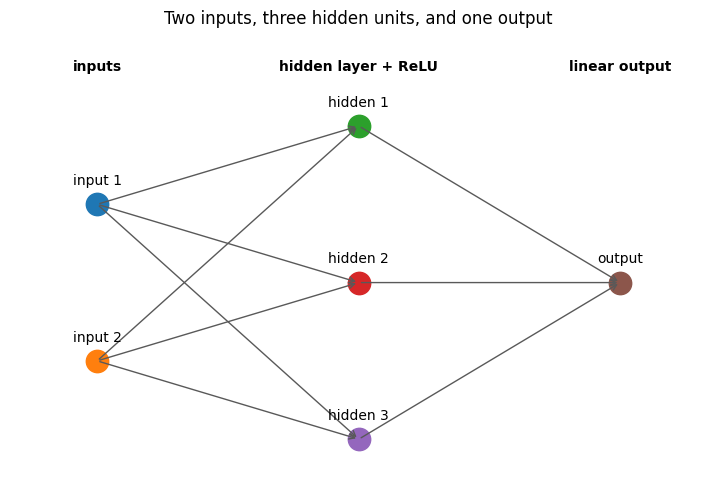

In [9]:
import matplotlib.pyplot as plt

network_node_positions = {
    "input 1": (0.0, 2.5),
    "input 2": (0.0, 0.5),
    "hidden 1": (3.0, 3.5),
    "hidden 2": (3.0, 1.5),
    "hidden 3": (3.0, -0.5),
    "output": (6.0, 1.5),
}
network_edges = [
    (input_name, hidden_name)
    for input_name in ("input 1", "input 2")
    for hidden_name in ("hidden 1", "hidden 2", "hidden 3")
] + [(hidden_name, "output") for hidden_name in ("hidden 1", "hidden 2", "hidden 3")]

plt.figure(figsize=(9, 6))

for start_name, end_name in network_edges:
    start_position = network_node_positions[start_name]
    end_position = network_node_positions[end_name]
    plt.annotate(
        "",
        xy=end_position,
        xytext=start_position,
        arrowprops={"arrowstyle": "->", "color": "0.35"},
    )

for node_name, (x_position, y_position) in network_node_positions.items():
    plt.scatter([x_position], [y_position], s=260)
    plt.text(x_position, y_position + 0.25, node_name, ha="center")

plt.text(0.0, 4.2, "inputs", ha="center", weight="bold")
plt.text(3.0, 4.2, "hidden layer + ReLU", ha="center", weight="bold")
plt.text(6.0, 4.2, "linear output", ha="center", weight="bold")
plt.xlim(-1.0, 7.0)
plt.ylim(-1.2, 4.7)
plt.axis("off")
plt.title("Two inputs, three hidden units, and one output")
plt.show()

## Count parameters by hand

A neuron receiving `n` inputs has `n` weights and one bias, for `n + 1` parameters.

A dense layer with `I` inputs and `O` neurons has:

```text
O × (I + 1)
```

For the `2 → 3 → 1` network:

```text
hidden layer: 3 × (2 + 1) = 9
output layer: 1 × (3 + 1) = 4
total: 9 + 4 = 13
```

In [10]:
hidden_parameter_count = example_network.hidden_layer.parameter_count()
output_parameter_count = example_network.output_layer.parameter_count()
total_parameter_count = example_network.parameter_count()

print("Hidden layer parameters:", hidden_parameter_count)
print("Output layer parameters:", output_parameter_count)
print("Total parameters:", total_parameter_count)

assert hidden_parameter_count == 9
assert output_parameter_count == 4
assert total_parameter_count == 13
assert total_parameter_count == len(example_network.parameters())

Hidden layer parameters: 9
Output layer parameters: 4
Total parameters: 13


## General parameter-count formula

For input width `I`, hidden width `H`, and output width `O`, this two-layer network has:

```text
H × (I + 1) + O × (H + 1)
```

The weight count of a dense layer is the product of adjacent widths.

Increasing only `H` with fixed `I` and `O` produces linear growth, while scaling both sides of a dense connection can produce quadratic growth.

In [11]:
def count_two_layer_parameters(
    number_of_inputs: int,
    number_of_hidden_units: int,
    number_of_outputs: int,
) -> int:
    hidden_count = number_of_hidden_units * (number_of_inputs + 1)
    output_count = number_of_outputs * (number_of_hidden_units + 1)
    return hidden_count + output_count


parameter_examples = [
    (2, 3, 1),
    (10, 20, 1),
    (100, 100, 10),
    (1000, 512, 100),
]

print("inputs | hidden | outputs | parameters")
print("-" * 46)
for input_width, hidden_width, output_width in parameter_examples:
    count = count_two_layer_parameters(input_width, hidden_width, output_width)
    print(f"{input_width:>6} | {hidden_width:>6} | {output_width:>7} | {count:>10,}")

assert count_two_layer_parameters(2, 3, 1) == 13
assert count_two_layer_parameters(1000, 512, 100) == 563_812

inputs | hidden | outputs | parameters
----------------------------------------------
     2 |      3 |       1 |         13
    10 |     20 |       1 |        241
   100 |    100 |      10 |     11,110
  1000 |    512 |     100 |    563,812


## Visualize growth with hidden width

With input and output widths fixed, every added hidden unit introduces another input-weight row, hidden bias, and output-weight column.

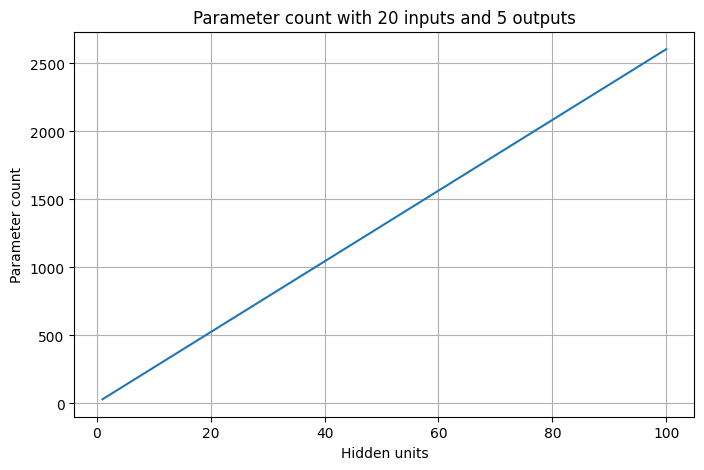

In [12]:
growth_hidden_widths = list(range(1, 101))
growth_parameter_counts = [
    count_two_layer_parameters(20, hidden_width, 5)
    for hidden_width in growth_hidden_widths
]

plt.figure(figsize=(8, 5))
plt.plot(growth_hidden_widths, growth_parameter_counts)
plt.xlabel("Hidden units")
plt.ylabel("Parameter count")
plt.title("Parameter count with 20 inputs and 5 outputs")
plt.grid(True)
plt.show()

## Create a tiny training dataset

Use the obvious target `first input + second input`.

This affine target does not require a hidden layer, so the exercise is an end-to-end smoke test of multilayer forward passes, autograd, and parameter updates rather than evidence of extra nonlinear expressivity.

In [13]:
training_inputs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [2.0, 1.0],
    [1.0, 2.0],
]
training_targets = [0.0, 1.0, 1.0, 2.0, 3.0, 3.0]

print("input values | target")
print("-" * 28)
for training_input, training_target in zip(
    training_inputs,
    training_targets,
    strict=True,
):
    print(f"{str(training_input):>12} | {training_target:>6.2f}")

input values | target
----------------------------
  [0.0, 0.0] |   0.00
  [0.0, 1.0] |   1.00
  [1.0, 0.0] |   1.00
  [1.0, 1.0] |   2.00
  [2.0, 1.0] |   3.00
  [1.0, 2.0] |   3.00


## Average squared error

One forward pass over the dataset creates one graph containing every example's loss.

Calling `backward()` on their average accumulates each example's contribution into every shared parameter gradient.

In [14]:
def validate_network_dataset(
    training_inputs: list[list[float]],
    training_targets: list[float],
    expected_input_count: int,
) -> None:
    if len(training_inputs) != len(training_targets):
        raise ValueError("Inputs and targets must have the same length.")

    if not training_inputs:
        raise ValueError("The training dataset must not be empty.")

    if any(
        len(input_values) != expected_input_count for input_values in training_inputs
    ):
        raise ValueError("Every example must match the network input width.")


def average_network_loss(
    network: SmallNeuralNetwork,
    training_inputs: list[list[float]],
    training_targets: list[float],
) -> TrackedNumber:
    validate_network_dataset(
        training_inputs,
        training_targets,
        network.number_of_inputs,
    )
    total_loss = TrackedNumber(0.0, label="total_loss_start")

    for input_values, target_value in zip(
        training_inputs,
        training_targets,
        strict=True,
    ):
        prediction = network(input_values)[0]
        example_loss = (prediction - target_value) ** 2
        total_loss = total_loss + example_loss

    average_loss = total_loss / len(training_inputs)
    average_loss.label = "average_loss"
    return average_loss


def predict_dataset(
    network: SmallNeuralNetwork,
    input_rows: list[list[float]],
) -> list[float]:
    return [network(input_values)[0].data for input_values in input_rows]

## Train the network

Each step follows the familiar order: forward pass, loss, clear gradients, backward pass, and parameter update.

Parameter `data` is updated directly so the optimizer step does not become part of the next computation graph.

In [15]:
trained_network = SmallNeuralNetwork(
    number_of_inputs=2,
    number_of_hidden_units=3,
    number_of_outputs=1,
    random_seed=RANDOM_SEED,
)
trained_parameters = trained_network.parameters()
predictions_before_training = predict_dataset(trained_network, training_inputs)

learning_rate = 0.03
number_of_steps = 1000
training_history: list[dict[str, float]] = []

for training_step in range(number_of_steps):
    training_loss = average_network_loss(
        trained_network,
        training_inputs,
        training_targets,
    )
    clear_gradients(trained_parameters)
    training_loss.backward()

    training_history.append({"step": float(training_step), "loss": training_loss.data})

    for trained_parameter in trained_parameters:
        trained_parameter.data -= learning_rate * trained_parameter.gradient

predictions_after_training = predict_dataset(trained_network, training_inputs)
initial_training_loss = training_history[0]["loss"]
final_training_loss = training_history[-1]["loss"]

print("Parameter count:", trained_network.parameter_count())
print("Initial loss:", initial_training_loss)
print("Final loss:", final_training_loss)

assert trained_network.parameter_count() == 13
assert final_training_loss < initial_training_loss * 0.001
assert (
    max(
        abs(prediction - target)
        for prediction, target in zip(
            predictions_after_training,
            training_targets,
            strict=True,
        )
    )
    < 0.01
)

Parameter count: 13
Initial loss: 4.385441436916377
Final loss: 2.6073089288670363e-06


## Plot the training result

The left plot shows optimization progress, while the right plot compares predictions before and after training.

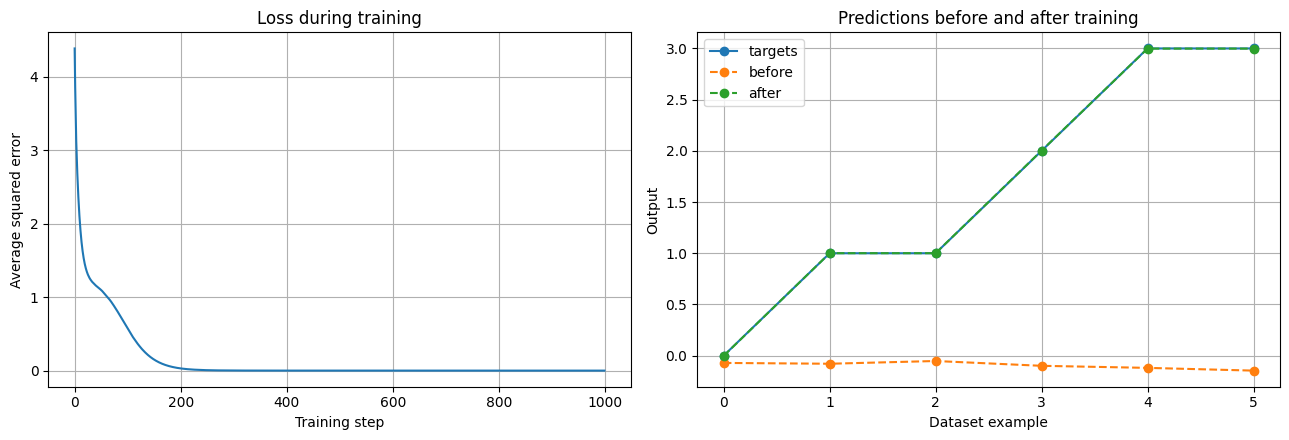

In [16]:
history_steps = [row["step"] for row in training_history]
history_losses = [row["loss"] for row in training_history]
example_positions = list(range(len(training_targets)))

training_figure, training_axes = plt.subplots(1, 2, figsize=(13, 4.5))
training_axes[0].plot(history_steps, history_losses)
training_axes[0].set_xlabel("Training step")
training_axes[0].set_ylabel("Average squared error")
training_axes[0].set_title("Loss during training")
training_axes[0].grid(True)

training_axes[1].plot(
    example_positions,
    training_targets,
    "o-",
    label="targets",
)
training_axes[1].plot(
    example_positions,
    predictions_before_training,
    "o--",
    label="before",
)
training_axes[1].plot(
    example_positions,
    predictions_after_training,
    "o--",
    label="after",
)
training_axes[1].set_xlabel("Dataset example")
training_axes[1].set_ylabel("Output")
training_axes[1].set_title("Predictions before and after training")
training_axes[1].set_xticks(example_positions)
training_axes[1].legend()
training_axes[1].grid(True)

training_figure.tight_layout()
plt.show()

## Print final predictions

The trained outputs closely match the easy sum targets.

In [17]:
print("input values | target | before | after")
print("-" * 54)
for final_input, final_target, before_value, after_value in zip(
    training_inputs,
    training_targets,
    predictions_before_training,
    predictions_after_training,
    strict=True,
):
    print(
        f"{str(final_input):>12} | {final_target:>6.2f} | "
        f"{before_value:>8.4f} | {after_value:>8.4f}"
    )

input values | target | before | after
------------------------------------------------------
  [0.0, 0.0] |   0.00 |  -0.0711 |  -0.0015
  [0.0, 1.0] |   1.00 |  -0.0791 |   1.0006
  [1.0, 0.0] |   1.00 |  -0.0523 |   1.0005
  [1.0, 1.0] |   2.00 |  -0.0992 |   2.0026
  [2.0, 1.0] |   3.00 |  -0.1194 |   2.9983
  [1.0, 2.0] |   3.00 |  -0.1461 |   2.9983


## Inspect trained parameters

Every parameter received a gradient and an update, but individual values are less interpretable than in a one-weight model.

Different hidden-unit arrangements can implement similar overall functions, so network behavior and loss are usually more informative than one scalar parameter in isolation.

In [18]:
print("parameter".ljust(32), "data".rjust(12), "last gradient".rjust(16))
print("-" * 62)
for inspected_parameter in trained_network.parameters():
    print(
        inspected_parameter.label.ljust(32),
        f"{inspected_parameter.data:>12.6f}",
        f"{inspected_parameter.gradient:>16.6f}",
    )

parameter                                data    last gradient
--------------------------------------------------------------
hidden_layer.neuron_0.weight_0      -0.402931         0.001089
hidden_layer.neuron_0.weight_1      -0.402916         0.001091
hidden_layer.neuron_0.bias           1.208746         0.000754
hidden_layer.neuron_1.weight_0      -0.295544        -0.000333
hidden_layer.neuron_1.weight_1      -0.274525         0.000206
hidden_layer.neuron_1.bias           0.858625        -0.000024
hidden_layer.neuron_2.weight_0      -0.238808         0.000184
hidden_layer.neuron_2.weight_1      -0.260709        -0.000344
hidden_layer.neuron_2.bias           0.752873        -0.000035
output_layer.neuron_0.weight_0      -1.316677        -0.000025
output_layer.neuron_0.weight_1      -0.897319        -0.000024
output_layer.neuron_0.weight_2      -0.863895        -0.000022
output_layer.neuron_0.bias           3.010906        -0.000573


## Why nonlinear hidden layers matter

Composing affine layers without activations collapses exactly into one affine function.

ReLU prevents that collapse by changing the formula in different input regions.

The current sum dataset is affine, so it deliberately checks implementation and training rather than demonstrating that advantage.

## Why parameter count matters

More parameters require more storage, more gradient values, and more arithmetic in forward and backward passes.

They can increase a model's capacity, but they can also increase training cost and overfitting risk.

Large language models repeat dense and other parameterized transformations across many wide layers, which is why their parameter counts become enormous.

## What not to do

- Do not treat a layer as mysterious; it is a group of neurons receiving the same inputs.
- Do not forget that every neuron owns separate weights and a bias.
- Do not omit nonlinearities and expect depth alone to create nonlinear functions.
- Do not apply ReLU automatically to a regression output whose range may include negative values.
- Do not forget to clear parameter gradients before each backward pass.
- Do not infer model quality from parameter count alone.
- Do not claim this affine training target demonstrates hidden-layer expressivity.

## Gotchas

### Layer outputs form the next layer's inputs

A layer with three neurons returns three values, so the next layer must expect three inputs.

### Parameter counts include biases

Each neuron contributes one bias in addition to its incoming weights.

### ReLU can block gradients

An inactive hidden unit sends zero gradient through its ReLU for that example.

### Initialization affects training

The fixed seed makes this notebook reproducible, while small positive hidden biases reduce the chance that every ReLU begins inactive on these nonnegative inputs.

### Every training step builds a new graph

Updating parameter data does not recompute old outputs, so the next step must run a new forward pass.

## Takeaways

A `SingleNeuron` maps several inputs to one output.

A `Layer` calls several neurons on the same inputs and returns several outputs.

A `SmallNeuralNetwork` passes one layer's outputs into the next layer.

The `2 → 3 → 1` network contains 13 parameters:

```text
3 × (2 + 1) + 1 × (3 + 1) = 13
```

Homemade autograd computes gradients for all 13 parameters through the same backward call.

Training still follows the familiar sequence:

```text
forward pass → loss → clear gradients → backward pass → update parameters
```

## What comes next

The next chapter replaces homemade scalar objects with PyTorch tensors and PyTorch autograd.

The implementation becomes more efficient, but the conceptual pattern remains the same: layers contain parameters, forward passes build computations, and backward passes produce gradients.